<a href="https://colab.research.google.com/github/ajengfirdyaramadany-bot/UTS-Credit-Default-Prediction-Modern-Machine-Learning/blob/main/UTS_PREDIKSI_MODERN_%26_MACHINE_LEARNING_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ULANGAN TENGAH SEMESTER**

Prediksi Modern & Machine Learning

Nama: Ajeng Firdya Ramadany

NIM : 2404220007

Tujuan notebook ini adalah memprediksi apakah nasabah kartu kredit akan mengalami default pada bulan berikutnya (default.payment.next.month, dengan 0 berarti tidak default dan 1 berarti default). Dataset yang dipakai adalah Default of Credit Card Clients dengan 30.000 nasabah di Taiwan.

Prosedur evaluasi sama di semua eksperimen. Data dibagi 80% untuk train dan 20% untuk test secara stratified dengan random_state 42. Cross validation 5-fold dilakukan hanya pada training set. Metrik utama adalah F1-score, sedangkan Accuracy, Precision, dan Recall menjadi metrik pendukung. Seluruh preprocessing dimasukkan ke dalam Pipeline agar tidak terjadi data leakage.

## **Experiment 0 - Data Understanding & Preparation**

**Import Library**

In [1]:
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier   # jika error: !pip install xgboost

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

**Load Dataset**

Experiment 0: Data Understanding dan Data Preparation. Langkah pertama adalah membaca dataset. Dataset dibaca dalam bentuk mentah dari file UCI_Credit_Card.csv sesuai ketentuan dosen, tanpa modifikasi apa pun sebelum tahap pemeriksaan.

In [2]:
from google.colab import files
uploaded = files.upload()   # pilih UCI_Credit_Card.csv

df = pd.read_csv("/content/UCI_Credit_Card.csv")
df.head()

Saving UCI_Credit_Card.csv to UCI_Credit_Card (1).csv


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


**Dimensi, struktur, tipe data**

Melihat dimensi, struktur, dan tipe data. Langkah ini memastikan jumlah data sesuai deskripsi tugas dan melihat tipe setiap kolom. Hasilnya, dataset berukuran 30.000 baris dan 25 kolom, sesuai deskripsi tugas. Semua kolom bertipe numerik sehingga tidak ada kolom teks yang perlu diubah. Kolom SEX, EDUCATION, dan MARRIAGE memang bertipe angka, tetapi sebenarnya kategorikal sehingga perlu penanganan khusus saat preprocessing.

In [3]:
print("Dimensi dataset (baris, kolom):", df.shape)
print()
df.info()

Dimensi dataset (baris, kolom): (30000, 25)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null 

**Statistik Deskriptif**

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


**Target, missing value, duplicate**

Memeriksa variabel target, missing value, dan duplicate. Variabel target adalah default.payment.next.month. Jumlah missing value adalah nol sehingga tidak diperlukan imputasi. Tidak ada baris duplikat jika kolom ID ikut dihitung. Ada 35 baris yang identik jika kolom ID diabaikan, tetapi baris ini tidak dihapus karena setiap baris adalah nasabah yang berbeda (ID-nya unik) dan kesamaan nilai pada fitur diskret masih wajar terjadi secara kebetulan.

In [5]:
TARGET = "default.payment.next.month"
print("Variabel target:", TARGET)
print("Total missing value:", int(df.isna().sum().sum()))
print("Duplicate (semua kolom, termasuk ID):", int(df.duplicated().sum()))
print("Duplicate (tanpa kolom ID):", int(df.drop(columns='ID').duplicated().sum()))

Variabel target: default.payment.next.month
Total missing value: 0
Duplicate (semua kolom, termasuk ID): 0
Duplicate (tanpa kolom ID): 35


**Cek nilai tidak wajar**

Memeriksa nilai yang tidak sesuai atau tidak wajar. Nilai setiap kolom kategorikal dibandingkan dengan dokumentasi dataset. Kolom EDUCATION berisi nilai 0, 5, dan 6 yang tidak ada di dokumentasi (total 345 baris), sehingga nilai tersebut digabung ke kategori 4 (others). Kolom MARRIAGE berisi nilai 0 sebanyak 54 baris yang juga tidak terdokumentasi, sehingga digabung ke kategori 3 (others).

Kolom PAY_0 sampai PAY_6 memiliki nilai -2 dan 0 yang tidak dijelaskan dokumentasi. Nilai ini dibiarkan karena jumlahnya sangat besar dan merepresentasikan status pembayaran yang bermakna, sehingga menghapusnya akan membuang informasi penting. BILL_AMT yang bernilai negatif adalah kondisi wajar karena nasabah bisa kelebihan bayar, jadi tidak dibuang. AGE (21 sampai 79) dan LIMIT_BAL berada pada rentang yang masuk akal. Outlier pada kolom nominal uang adalah nilai nyata dari nasabah dengan limit atau tagihan besar, sehingga tidak dihapus.

In [6]:
for c in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(c, df[c].value_counts().sort_index().to_dict())

print()
for c in ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]:
    print(c, df[c].value_counts().sort_index().to_dict())

bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
print()
print("Jumlah BILL_AMT negatif:", int((df[bill_cols] < 0).sum().sum()))
print("Rentang AGE:", df['AGE'].min(), "-", df['AGE'].max())

SEX {1: 11888, 2: 18112}
EDUCATION {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE {0: 54, 1: 13659, 2: 15964, 3: 323}

PAY_0 {-2: 2759, -1: 5686, 0: 14737, 1: 3688, 2: 2667, 3: 322, 4: 76, 5: 26, 6: 11, 7: 9, 8: 19}
PAY_2 {-2: 3782, -1: 6050, 0: 15730, 1: 28, 2: 3927, 3: 326, 4: 99, 5: 25, 6: 12, 7: 20, 8: 1}
PAY_3 {-2: 4085, -1: 5938, 0: 15764, 1: 4, 2: 3819, 3: 240, 4: 76, 5: 21, 6: 23, 7: 27, 8: 3}
PAY_4 {-2: 4348, -1: 5687, 0: 16455, 1: 2, 2: 3159, 3: 180, 4: 69, 5: 35, 6: 5, 7: 58, 8: 2}
PAY_5 {-2: 4546, -1: 5539, 0: 16947, 2: 2626, 3: 178, 4: 84, 5: 17, 6: 4, 7: 58, 8: 1}
PAY_6 {-2: 4895, -1: 5740, 0: 16286, 2: 2766, 3: 184, 4: 49, 5: 13, 6: 19, 7: 46, 8: 2}

Jumlah BILL_AMT negatif: 3932
Rentang AGE: 21 - 79


**Distribusi Target**

Melihat distribusi variabel target. Hasilnya, 23.364 nasabah tidak default (77,88%) dan 6.636 nasabah default (22,12%), sehingga target tidak seimbang. Akibatnya, Accuracy bisa menyesatkan karena model yang selalu menebak tidak default saja sudah mencapai sekitar 78% Accuracy tanpa mendeteksi satu pun nasabah berisiko. Karena itu F1-score dipilih sebagai metrik utama dan class imbalance perlu ditangani pada tahap preprocessing. Grafik di sebelah kanan juga menunjukkan bahwa PAY_0 sangat berkaitan dengan peluang default.

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


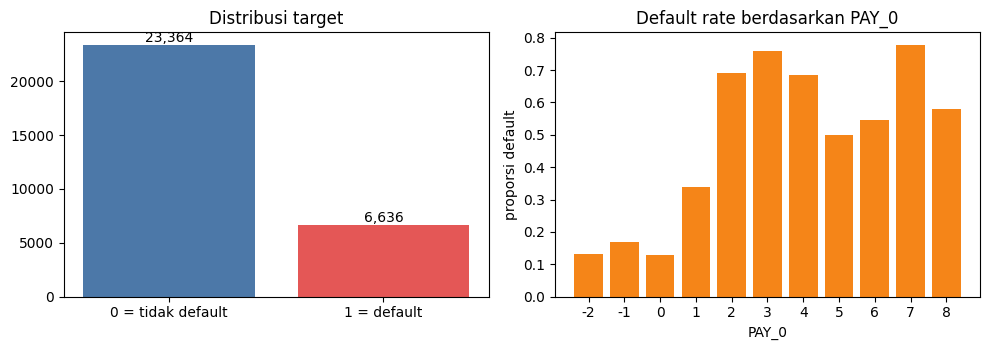

In [7]:
vc = df[TARGET].value_counts().sort_index()
print(vc)
print((df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].bar(["0 = tidak default", "1 = default"], vc.values, color=["#4C78A8", "#E45756"])
ax[0].set_title("Distribusi target")
for i, v in enumerate(vc.values):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

rate = df.groupby("PAY_0")[TARGET].mean()
ax[1].bar(rate.index.astype(str), rate.values, color="#F58518")
ax[1].set_title("Default rate berdasarkan PAY_0")
ax[1].set_xlabel("PAY_0"); ax[1].set_ylabel("proporsi default")
plt.tight_layout(); plt.show()

**Predictor, target, train-test split**

Menentukan predictor dan target serta melakukan train-test split. Target (y) adalah default.payment.next.month, sedangkan predictor (X) adalah 23 kolom lainnya. Kolom ID dikeluarkan karena hanya identitas baris dan tidak mengandung informasi prediktif.

Data dibagi menjadi 80% train (24.000 baris) dan 20% test (6.000 baris) dengan stratify agar proporsi default tetap sama di kedua bagian (sekitar 22%), dan dengan random_state 42 agar hasil dapat direproduksi. Pembagian dilakukan sebelum preprocessing dan training, sehingga test set benar-benar data yang belum pernah dilihat model dan data leakage dapat dicegah. Cross validation 5-fold didefinisikan satu kali dan dipakai di semua eksperimen agar perbandingan antar model adil.

In [8]:
X = df.drop(columns=["ID", TARGET])   # ID dikeluarkan
y = df[TARGET]
print("Jumlah predictor:", X.shape[1])

# Split SEBELUM preprocessing/training (mencegah data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Proporsi default train:", round(y_train.mean(), 4), "| test:", round(y_test.mean(), 4))

# 5-fold CV yang sama dipakai di semua eksperimen
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Jumlah predictor: 23
Train: (24000, 23) | Test: (6000, 23)
Proporsi default train: 0.2212 | test: 0.2212


**Definisi preprocessing (di dalam Pipeline, bebas leakage)**

Preprocessing yang dipilih. Seluruh langkah dibungkus dalam Pipeline sehingga scaler dan encoder hanya di-fit pada data latih di setiap fold. Dengan begitu data validation fold dan test set tidak ikut memengaruhi parameter preprocessing, dan tidak terjadi data leakage.

Langkah pertama adalah menggabungkan kategori yang tidak valid pada EDUCATION dan MARRIAGE sesuai temuan sebelumnya. Langkah kedua adalah One-Hot Encoding untuk SEX, EDUCATION, dan MARRIAGE, karena ketiganya kategori nominal dan jika dipakai sebagai angka, model akan mengira ada urutan atau jarak antar kategori. Langkah ketiga adalah StandardScaler untuk fitur numerik karena skalanya sangat berbeda (LIMIT_BAL puluhan ribu, sedangkan PAY_x hanya 0 sampai 8), dan ini penting terutama untuk Logistic Regression.

Teknik yang tidak dilakukan adalah imputasi karena tidak ada missing value, penghapusan outlier karena nilainya nyata, dan penghapusan duplikat karena bukan duplikat sebenarnya. Efek preprocessing ini diuji secara eksperimen pada Experiment 2.

In [9]:
def clean_categories(d):
    d = d.copy()
    d["EDUCATION"] = d["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
    d["MARRIAGE"] = d["MARRIAGE"].replace({0: 3})
    return d

CAT_COLS = ["SEX", "EDUCATION", "MARRIAGE"]
NUM_COLS = [c for c in X.columns if c not in CAT_COLS]

def make_preprocessor():
    return Pipeline([
        ("clean", FunctionTransformer(clean_categories)),
        ("encode_scale", ColumnTransformer([
            ("num", StandardScaler(), NUM_COLS),
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT_COLS),
        ])),
    ])

def make_pipeline(clf):
    return Pipeline([("prep", make_preprocessor()), ("clf", clf)])

**Fungsi Evaluasi**

Fungsi evaluasi. Fungsi evaluate() dipakai untuk semua eksperimen agar prosedurnya identik. Fungsi ini menghitung CV F1 (rata-rata 5-fold pada training set), lalu melatih model pada seluruh training set dan menghitung Accuracy, Precision, Recall, dan F1 pada test set. Hasil setiap eksperimen disimpan di list results untuk tabel ringkasan akhir.

In [10]:
results = []   # menyimpan hasil semua eksperimen

def evaluate(name, exp, model, Xtr, ytr, Xte, yte, cv_f1=None, fitted=False):
    """5-fold CV (F1) pada training set + evaluasi pada test set."""
    if cv_f1 is None:
        scores = cross_val_score(model, Xtr, ytr, cv=cv5, scoring="f1")
        cv_f1, cv_std = scores.mean(), scores.std()
    else:
        cv_std = np.nan
    if not fitted:
        model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    row = {
        "Experiment": exp, "Model": name,
        "CV F1": cv_f1, "CV F1 Std": cv_std,
        "Test Accuracy": accuracy_score(yte, pred),
        "Test Precision": precision_score(yte, pred, zero_division=0),
        "Test Recall": recall_score(yte, pred),
        "Test F1": f1_score(yte, pred),
    }
    results.append(row)
    return row

def show(rows):
    out = pd.DataFrame(rows).drop(columns=["CV F1 Std"]).set_index(["Experiment", "Model"])
    return out.round(4)

## **Experiment 1, baseline (data mentah)**

Tujuannya membuat titik acuan untuk membandingkan seluruh eksperimen berikutnya. Modelnya adalah Logistic Regression pada data mentah, tanpa scaling, tanpa encoding, dan tanpa perapian kategori. Parameter max_iter dinaikkan menjadi 1000 agar solver dapat konvergen.

In [11]:
baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
r1 = evaluate("Logistic Regression (raw)", "1", baseline, X_train, y_train, X_test, y_test)
show([r1])

,,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment,Model,,,,,
1,Logistic Regression (raw),0.3525,0.8037,0.663,0.2283,0.3397


Hasil dan interpretasi Experiment 1: CV F1 sebesar 0,3525, Test F1 sebesar 0,3397, Accuracy 0,8037, Precision 0,6630, dan Recall 0,2283. Accuracy terlihat tinggi, tetapi Recall hanya 0,2283, artinya model hanya mendeteksi sekitar 23% nasabah yang benar-benar default. Ini sesuai dugaan sebelumnya bahwa target yang tidak seimbang membuat Accuracy menyesatkan. Nilai F1 sebesar 0,3397 menjadi baseline untuk eksperimen berikutnya.

## **Experiment 2, preprocessing**

Preprocessing dipilih berdasarkan temuan di Experiment 0. Kategori EDUCATION dan MARRIAGE yang tidak valid digabung ke kategori others, kolom SEX, EDUCATION, dan MARRIAGE diubah dengan One-Hot Encoding karena berupa kategori nominal, dan fitur numerik di-scaling dengan StandardScaler karena skalanya sangat berbeda. Selain itu ditambahkan class_weight balanced karena hanya 22% nasabah yang berlabel default. Preprocessing dibagi menjadi tahap 2a (kategori, encoding, scaling) dan tahap 2b (tahap 2a ditambah class_weight) agar pengaruh masing-masing terlihat. Semua langkah berada di dalam Pipeline sehingga tidak terjadi data leakage.

In [12]:
# 2a: perapian kategori + OneHot + StandardScaler
lr_2a = make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
r2a = evaluate("LR + clean/encode/scale", "2a", lr_2a, X_train, y_train, X_test, y_test)

# 2b: 2a + penanganan class imbalance
lr_2b = make_pipeline(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
r2b = evaluate("LR + clean/encode/scale + class_weight", "2b", lr_2b, X_train, y_train, X_test, y_test)

show([r1, r2a, r2b])

,,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment,Model,,,,,
1,Logistic Regression (raw),0.3525,0.8037,0.6630,0.2283,0.3397
2a,LR + clean/encode/scale,0.3641,0.8088,0.6923,0.2442,0.3610
2b,LR + clean/encode/scale + class_weight,0.4812,0.6787,0.3679,0.6307,0.4647


**Selisih terhadap baseline**

In [13]:
cols = ["CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]
d = pd.DataFrame([r2a, r2b]).set_index("Experiment")[cols] - pd.Series({k: r1[k] for k in cols})
d.round(4)

,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment,,,,,
2a,0.0117,0.0052,0.0293,0.0158,0.0213
2b,0.1288,-0.1250,-0.2951,0.4024,0.1251


Hasil Experiment 2. Baseline memiliki CV F1 0,3525 dan Test F1 0,3397. Tahap 2a menghasilkan CV F1 0,3641 dan Test F1 0,3610, sehingga naik kecil tetapi konsisten pada CV maupun test. Tahap 2b menghasilkan CV F1 0,4812 dan Test F1 0,4647, dengan Recall naik dari 0,2283 menjadi 0,6307. Harganya, Accuracy turun dari 0,8037 menjadi 0,6787 dan Precision turun dari 0,6630 menjadi 0,3679, tetapi ini wajar karena F1 menyeimbangkan keduanya dan tujuan utamanya menangkap nasabah berisiko.

Jawaban: ya, preprocessing meningkatkan performa model, dengan F1 naik dari 0,3397 menjadi 0,4647 pada test set. Peningkatan terbesar berasal dari penanganan class imbalance, sedangkan scaling dan encoding hanya memberi tambahan kecil. Tahap 2b dipakai untuk eksperimen berikutnya karena CV F1-nya tertinggi.

## **Experiment 3, perbandingan modell**

Tujuannya membandingkan tiga model dengan prosedur yang sama untuk menentukan model terbaik. Logistic Regression, Decision Tree, dan Random Forest memakai preprocessing 2b yang sama (termasuk class_weight balanced), cross validation 5-fold yang sama, dan test set yang sama. Hyperparameter masih default, kecuali Random Forest yang memakai n_estimators 200. Model terbaik ditentukan dari CV F1 dan bukan dari test set, agar test set tidak dipakai untuk memilih model.

In [14]:
models3 = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                            random_state=RANDOM_STATE, n_jobs=-1),
}
rows3 = []
for name, clf in models3.items():
    rows3.append(evaluate(name, "3", make_pipeline(clf), X_train, y_train, X_test, y_test))

show(rows3)

CV F1  Test Accuracy  Test Precision  Test Recall  Test F1
Experiment Model                                                                           
3          Logistic Regression  0.4812         0.6787          0.3679       0.6307   0.4647
           Decision Tree        0.3931         0.7272          0.3854       0.3926   0.3890
           Random Forest        0.4619         0.8137          0.6486       0.3436   0.4493

**Model Terbaik**

In [15]:
df3 = pd.DataFrame(rows3).set_index("Model")
best_model_name = df3["CV F1"].idxmax()
print("Model terbaik Experiment 3 (berdasarkan CV F1):", best_model_name)
print()
print(df3[["CV F1", "CV F1 Std", "Test F1"]].round(4))

Model terbaik Experiment 3 (berdasarkan CV F1): Logistic Regression

                      CV F1  CV F1 Std  Test F1
Model                                          
Logistic Regression  0.4812     0.0119   0.4647
Decision Tree        0.3931     0.0128   0.3890
Random Forest        0.4619     0.0064   0.4493


Hasil dan interpretasi Experiment 3. Logistic Regression mendapat CV F1 0,4812, Test Accuracy 0,6787, Precision 0,3679, Recall 0,6307, dan Test F1 0,4647. Decision Tree mendapat CV F1 0,3931, Accuracy 0,7272, Precision 0,3854, Recall 0,3926, dan Test F1 0,3890. Random Forest mendapat CV F1 0,4619, Accuracy 0,8137, Precision 0,6486, Recall 0,3436, dan Test F1 0,4493.

Logistic Regression terbaik pada CV F1 dan Test F1, dengan Recall tertinggi. Random Forest unggul pada Accuracy dan Precision tetapi Recall-nya rendah sehingga F1-nya lebih kecil. Decision Tree paling buruk karena pohon tanpa batas kedalaman cenderung overfitting. Keputusannya, Logistic Regression dipilih untuk Experiment 4, dan hasil ini menunjukkan bahwa model yang lebih kompleks tidak otomatis lebih baik pada metrik utama.

## **Experiment 4, GridSearchCVl**

Hyperparameter Tuning. Tujuannya mengetahui apakah tuning meningkatkan performa model terbaik dari Experiment 3, yaitu Logistic Regression. Tuning memakai GridSearchCV dengan cross validation 5-fold dan scoring F1. Hyperparameter yang diuji adalah C (kekuatan regularisasi) dengan nilai 0,001; 0,01; 0,1; 1; 10; dan 100, penalty dengan nilai l1 dan l2, serta class_weight dengan nilai None dan balanced. Totalnya ada 24 kombinasi dikali 5 fold. Solver liblinear dipakai karena mendukung penalty l1 maupun l2.

In [16]:
param_grids = {
    "Logistic Regression": {
        "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "clf__penalty": ["l1", "l2"],
        "clf__class_weight": [None, "balanced"],
    },
    "Decision Tree": {
        "clf__max_depth": [3, 5, 7, 10, None],
        "clf__min_samples_split": [2, 20, 50],
        "clf__min_samples_leaf": [1, 10, 30],
        "clf__criterion": ["gini", "entropy"],
    },
    "Random Forest": {
        "clf__n_estimators": [200],
        "clf__max_depth": [5, 10, None],
        "clf__min_samples_leaf": [1, 5, 20],
        "clf__max_features": ["sqrt", 0.5],
    },
}

def build_tuning_pipeline(name):
    if name == "Logistic Regression":
        clf = LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE)
    elif name == "Decision Tree":
        clf = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
    else:
        clf = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    return make_pipeline(clf)

grid = GridSearchCV(build_tuning_pipeline(best_model_name), param_grids[best_model_name],
                    scoring="f1", cv=cv5, n_jobs=-1, refit=True)
grid.fit(X_train, y_train)

print("Model yang di-tuning :", best_model_name)
print("Hyperparameter yang diuji:")
for k, v in param_grids[best_model_name].items():
    print(f"   {k}: {v}")
print()
print("Kombinasi terbaik :", grid.best_params_)
print("Best CV F1-score  :", round(grid.best_score_, 4))

Model yang di-tuning : Logistic Regression
Hyperparameter yang diuji:
   clf__C: [0.001, 0.01, 0.1, 1, 10, 100]
   clf__penalty: ['l1', 'l2']
   clf__class_weight: [None, 'balanced']

Kombinasi terbaik : {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1'}
Best CV F1-score  : 0.4839


**Evaluasi model tuned dan perbandingan sebelum vs sesudah**

In [17]:
r4 = evaluate(f"{best_model_name} (tuned)", "4", grid.best_estimator_, X_train, y_train, X_test, y_test,
              cv_f1=grid.best_score_, fitted=True)

top = pd.DataFrame(grid.cv_results_).sort_values("rank_test_score").head(8)
print("8 kombinasi teratas:")
display(top[["params", "mean_test_score", "std_test_score", "rank_test_score"]].round(4))

before = df3.loc[best_model_name]
cmp4 = pd.DataFrame({
    "Sebelum tuning (Exp 3)": [before["CV F1"], before["Test Accuracy"], before["Test Precision"], before["Test Recall"], before["Test F1"]],
    "Setelah tuning (Exp 4)": [r4["CV F1"], r4["Test Accuracy"], r4["Test Precision"], r4["Test Recall"], r4["Test F1"]],
}, index=["CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"])
cmp4["Selisih"] = cmp4["Setelah tuning (Exp 4)"] - cmp4["Sebelum tuning (Exp 3)"]
cmp4.round(4)

8 kombinasi teratas:


,params,mean_test_score,std_test_score,rank_test_score
10,"{'clf__C': 0.1, 'clf__class_weight': 'balanced...",0.4839,0.0123,1
7,"{'clf__C': 0.01, 'clf__class_weight': 'balance...",0.4833,0.0124,2
15,"{'clf__C': 1, 'clf__class_weight': 'balanced',...",0.4816,0.0114,3
22,"{'clf__C': 100, 'clf__class_weight': 'balanced...",0.4815,0.0115,4
19,"{'clf__C': 10, 'clf__class_weight': 'balanced'...",0.4814,0.0115,5
23,"{'clf__C': 100, 'clf__class_weight': 'balanced...",0.4814,0.0115,6
18,"{'clf__C': 10, 'clf__class_weight': 'balanced'...",0.4814,0.0116,7
11,"{'clf__C': 0.1, 'clf__class_weight': 'balanced...",0.4811,0.0113,8


,Sebelum tuning (Exp 3),Setelah tuning (Exp 4),Selisih
CV F1,0.4812,0.4839,0.0026
Test Accuracy,0.6787,0.6812,0.0025
Test Precision,0.3679,0.3704,0.0024
Test Recall,0.6307,0.6307,0.0000
Test F1,0.4647,0.4667,0.0019


Hasil dan interpretasi Experiment 4. Kombinasi terbaik adalah C 0,1, penalty l1, dan class_weight balanced, dengan best CV F1 sebesar 0,4839. Sebelum tuning, modelnya memiliki CV F1 0,4812, Accuracy 0,6787, Precision 0,3679, Recall 0,6307, dan Test F1 0,4647. Setelah tuning, CV F1 menjadi 0,4839, Accuracy 0,6812, Precision 0,3704, Recall tetap 0,6307, dan Test F1 0,4667.

Peningkatannya sangat kecil (CV F1 naik 0,0026 dan Test F1 naik 0,0019) dan jauh di bawah standar deviasi antar-fold yang sekitar 0,012. Kesimpulannya, tuning tidak memberi peningkatan yang berarti, dan Logistic Regression dengan pengaturan sebelumnya sudah hampir optimal. Grid search juga memilih class_weight balanced, yang mengonfirmasi keputusan pada Experiment 2.

## **Experiment 5, XGBoost**

Advanced Model dengan XGBoost. Tujuannya menguji apakah metode boosting lebih baik dari model terbaik pada Experiment 4. XGBoost memakai preprocessing pipeline yang sama. Class imbalance ditangani dengan scale_pos_weight, yaitu jumlah kelas 0 dibagi jumlah kelas 1 pada data training (nilainya 3,521). Hyperparameter dibuat konservatif untuk mengurangi overfitting, yaitu pohon dangkal (max_depth 3), learning rate kecil (0,05), n_estimators 300, dan subsampling 0,8.

In [18]:
spw = (y_train == 0).sum() / (y_train == 1).sum()   # hanya dari data training
print("scale_pos_weight:", round(spw, 3))

xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, eval_metric="logloss",
    random_state=RANDOM_STATE, n_jobs=-1,
)
r5 = evaluate("XGBoost", "5", make_pipeline(xgb), X_train, y_train, X_test, y_test)
show([r5])

scale_pos_weight: 3.521


,,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment,Model,,,,,
5,XGBoost,0.5398,0.7615,0.4708,0.6307,0.5391


**XGBoost vs model terbaik Exp 4**

In [19]:
m = ["CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]
cmp5 = pd.DataFrame({
    f"Terbaik Exp 4 ({best_model_name} tuned)": [r4[k] for k in m],
    "Advanced Exp 5 (XGBoost)": [r5[k] for k in m],
}, index=m)
cmp5["Selisih (XGB - Exp 4)"] = cmp5.iloc[:, 1] - cmp5.iloc[:, 0]
cmp5.round(4)

,Terbaik Exp 4 (Logistic Regression tuned),Advanced Exp 5 (XGBoost),Selisih (XGB - Exp 4)
CV F1,0.4839,0.5398,0.0559
Test Accuracy,0.6812,0.7615,0.0803
Test Precision,0.3704,0.4708,0.1004
Test Recall,0.6307,0.6307,0.0000
Test F1,0.4667,0.5391,0.0724


Hasil dan interpretasi Experiment 5. Logistic Regression tuned dari Experiment 4 memiliki CV F1 0,4839, Accuracy 0,6812, Precision 0,3704, Recall 0,6307, dan Test F1 0,4667. XGBoost memiliki CV F1 0,5398, Accuracy 0,7615, Precision 0,4708, Recall 0,6307, dan Test F1 0,5391.

XGBoost lebih baik, dengan CV F1 naik 0,0559 dan Test F1 naik 0,0724. Recall sama karena kedua model mendeteksi 837 dari 1.327 nasabah default, tetapi XGBoost jauh lebih sedikit salah alarm (941 dibanding 1.438), sehingga Precision dan Accuracy naik. CV F1 (0,5398) dan Test F1 (0,5391) hampir sama, yang menandakan model tidak overfitting.

**Tabel ringkasan semua eksperimen**

Final Summary. Tabel berikut merangkum seluruh eksperimen dan menjadi sumber angka untuk PDF Final Analysis. Baris Exp 2b (preprocessing ditambah class_weight) adalah baris Baseline + Preprocessing pada PDF.

In [20]:
summary = pd.DataFrame(results).drop(columns=["CV F1 Std"]).round(4)
summary = summary[["Experiment", "Model", "CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]]
summary.to_csv("results_summary.csv", index=False)
summary

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,1,Logistic Regression (raw),0.3525,0.8037,0.6630,0.2283,0.3397
1,2a,LR + clean/encode/scale,0.3641,0.8088,0.6923,0.2442,0.3610
2,2b,LR + clean/encode/scale + class_weight,0.4812,0.6787,0.3679,0.6307,0.4647
3,3,Logistic Regression,0.4812,0.6787,0.3679,0.6307,0.4647
4,3,Decision Tree,0.3931,0.7272,0.3854,0.3926,0.3890
5,3,Random Forest,0.4619,0.8137,0.6486,0.3436,0.4493
6,4,Logistic Regression (tuned),0.4839,0.6812,0.3704,0.6307,0.4667
7,5,XGBoost,0.5398,0.7615,0.4708,0.6307,0.5391


**Grafik perbandingan F1**

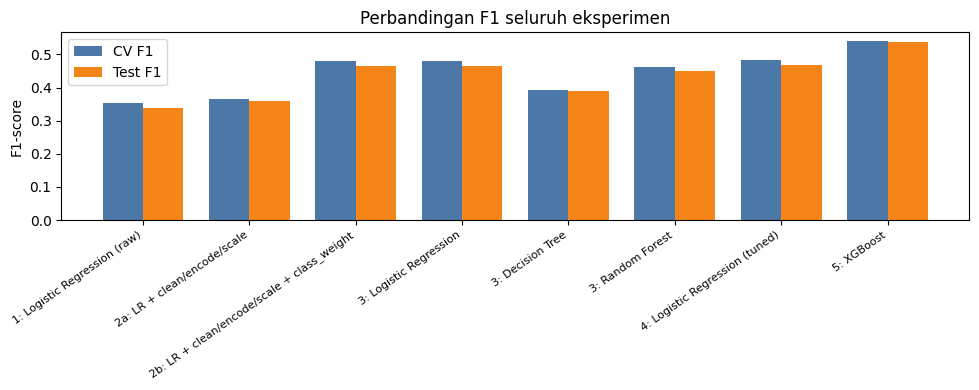

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
lab = [f"{r.Experiment}: {r.Model}" for r in summary.itertuples()]
x = np.arange(len(summary)); w = 0.38
ax.bar(x - w/2, summary["CV F1"], w, label="CV F1", color="#4C78A8")
ax.bar(x + w/2, summary["Test F1"], w, label="Test F1", color="#F58518")
ax.set_xticks(x); ax.set_xticklabels(lab, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("F1-score"); ax.set_title("Perbandingan F1 seluruh eksperimen"); ax.legend()
plt.tight_layout(); plt.show()

Interpretasi grafik perbandingan F1. Pada seluruh model, batang CV F1 dan Test F1 hampir sama tinggi dengan selisih paling besar sekitar 0,02, sehingga performa pada cross validation dan test set konsisten dan tidak ada tanda overfitting yang serius. Baseline mentah dan tahap 2a memiliki F1 terendah, sekitar 0,34 sampai 0,36. Lonjakan terbesar terjadi pada tahap 2b saat class_weight balanced ditambahkan, dengan F1 naik ke sekitar 0,47 sampai 0,48, sehingga penanganan class imbalance adalah keputusan preprocessing yang paling berpengaruh dibanding scaling dan encoding. Pada perbandingan model, Logistic Regression lebih tinggi daripada Random Forest dan Decision Tree, yang menunjukkan bahwa model yang lebih kompleks tidak otomatis lebih baik. Hyperparameter tuning hampir tidak mengubah tinggi batang, sehingga peningkatannya tidak berarti secara praktis. XGBoost menjadi model dengan F1 tertinggi baik pada CV (0,5398) maupun test (0,5391), dengan kedua batang yang hampir sama tinggi, sehingga dipilih sebagai model final.

**Analisis otomatis**

In [22]:
def pr(label, a, b, metrics=("CV F1","Test Accuracy","Test Precision","Test Recall","Test F1")):
    print(label)
    for mt in metrics:
        print(f"   {mt:15s}: {a[mt]:.4f} -> {b[mt]:.4f}  ({b[mt]-a[mt]:+.4f})")
    print()

pr("Q1. Baseline (Exp 1) -> Preprocessing 2a", r1, r2a)
pr("Q1. Baseline (Exp 1) -> Preprocessing 2b (+ class_weight)", r1, r2b)
print("Q2. Model terbaik Exp 3 (CV F1):", best_model_name)
print(df3[["CV F1","Test Accuracy","Test Precision","Test Recall","Test F1"]].round(4), "\n")
pr("Q3. Sebelum tuning -> Setelah tuning", before, r4)
pr("Q4. Tuned Exp 4 -> Advanced Exp 5 (XGBoost)", r4, r5)

Q1. Baseline (Exp 1) -> Preprocessing 2a
   CV F1          : 0.3525 -> 0.3641  (+0.0117)
   Test Accuracy  : 0.8037 -> 0.8088  (+0.0052)
   Test Precision : 0.6630 -> 0.6923  (+0.0293)
   Test Recall    : 0.2283 -> 0.2442  (+0.0158)
   Test F1        : 0.3397 -> 0.3610  (+0.0213)

Q1. Baseline (Exp 1) -> Preprocessing 2b (+ class_weight)
   CV F1          : 0.3525 -> 0.4812  (+0.1288)
   Test Accuracy  : 0.8037 -> 0.6787  (-0.1250)
   Test Precision : 0.6630 -> 0.3679  (-0.2951)
   Test Recall    : 0.2283 -> 0.6307  (+0.4024)
   Test F1        : 0.3397 -> 0.4647  (+0.1251)

Q2. Model terbaik Exp 3 (CV F1): Logistic Regression
                      CV F1  Test Accuracy  Test Precision  Test Recall  Test F1
Model                                                                           
Logistic Regression  0.4812         0.6787          0.3679       0.6307   0.4647
Decision Tree        0.3931         0.7272          0.3854       0.3926   0.3890
Random Forest        0.4619         0.8137

Experimental Analysis

**1. Apakah preprocessing pada Experiment 2 memberikan peningkatan performa dibandingkan
dengan baseline?**
Ya, preprocessing meningkatkan performa. Scaling dan encoding (2a) menaikkan CV F1 dari 0,3525 menjadi 0,3641 dan Test F1 dari 0,3397 menjadi 0,3610, sebuah peningkatan kecil tetapi konsisten. Penambahan class_weight balanced (2b) memberi peningkatan jauh lebih besar, yaitu CV F1 0,4812 dan Test F1 0,4647, dengan Recall naik dari 0,2283 menjadi 0,6307, sementara Accuracy turun dari 0,8037 menjadi 0,6787 dan Precision turun dari 0,6630 menjadi 0,3679. Jadi sebagian besar peningkatan berasal dari penanganan class imbalance.

**2. Model apa yang memberikan performa terbaik pada Experiment 3 sebelum dilakukan
hyperparameter tuning?**
Logistic Regression memberikan performa terbaik dengan CV F1 0,4812 dan Test F1 0,4647, mengungguli Random Forest (0,4619 dan 0,4493) dan Decision Tree (0,3931 dan 0,3890). Random Forest unggul pada Accuracy dan Precision tetapi Recall-nya rendah.

**3. Apakah hyperparameter tuning pada Experiment 4 meningkatkan performa model?**
Peningkatannya sangat kecil, yaitu CV F1 naik 0,0026 dan Test F1 naik 0,0019. Selisih ini lebih kecil dari variasi antar-fold sehingga secara praktis tidak berarti.

**4. Apakah model advanced pada Experiment 5 memberikan performa yang lebih baik dibandingkan
model terbaik dari eksperimen sebelumnya?**
Ya, XGBoost lebih baik dengan CV F1 0,5398 dibanding 0,4839 dan Test F1 0,5391 dibanding 0,4667, dengan Precision dan Accuracy lebih tinggi serta Recall yang setara.

**5. Berdasarkan seluruh eksperimen, model mana yang Anda pilih sebagai model final?**
Model final adalah XGBoost karena F1-nya tertinggi pada CV maupun test, Precision dan Accuracy-nya lebih baik dengan Recall yang setara dengan yang tertinggi, dan hasil CV serta test-nya konsisten sehingga tidak ada tanda overfitting. Keterbatasannya, hyperparameter XGBoost belum di-tuning dan interpretabilitasnya lebih rendah dibanding Logistic Regression.

##Kesimpulan:
1. penanganan class imbalance adalah keputusan preprocessing yang paling berpengaruh.
2.  model yang lebih kompleks tidak otomatis lebih baik, karena Logistic Regression mengalahkan Random Forest dan Decision Tree, dan tuning hanya menambah sedikit.
3. boosting (XGBoost) memberi peningkatan yang nyata dan konsisten sehingga dipilih sebagai model final.

**Confusion matrix model final**

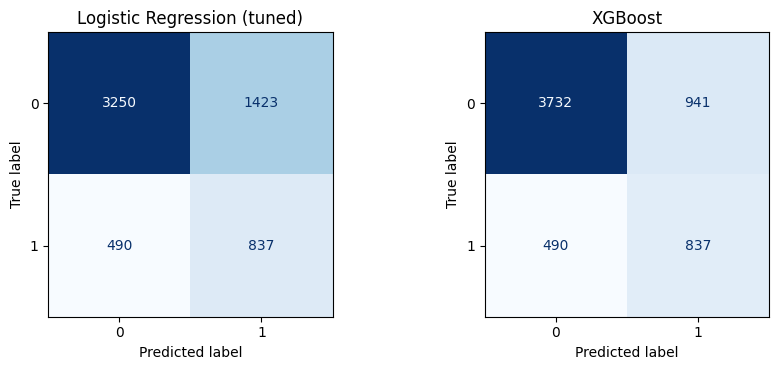

In [23]:
xgb_pipe = make_pipeline(XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)).fit(X_train, y_train)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
for a, (nm, mdl) in zip(ax, [(f"{best_model_name} (tuned)", grid.best_estimator_), ("XGBoost", xgb_pipe)]):
    ConfusionMatrixDisplay.from_estimator(mdl, X_test, y_test, ax=a, colorbar=False, cmap="Blues")
    a.set_title(nm)
plt.tight_layout(); plt.show()